In [1]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

taaf.kaggle: TRUE_SUBMISSION=False


In [2]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

0

In [3]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["thtennant/taaf-kaggle-source-share-fork", "driessmit1/arc3-vllm-h100-wheelhouse-v3"]
# --- v21: Qwen3.8-27B-FP8 model pin ------------------------------------------
# The one axis this project has never varied. Everything else in this notebook
# is byte-identical to v20; see scripts/build_v21_notebook.py.
QWEN_MODEL_OWNER = "foysalemonshanto"
QWEN_MODEL_SLUG = "qwen3-8-27b-fp8-repacked-v1"
QWEN_MODEL_REF = f"{QWEN_MODEL_OWNER}/{QWEN_MODEL_SLUG}"
QWEN_MODEL_FRAMEWORK = "pytorch"
QWEN_MODEL_VARIATION = "hf-fp8"
QWEN_MODEL_VERSION = "1"
QWEN_SERVED_MODEL_NAME = "Qwen/Qwen3.8-27B-FP8"

# Keep the whole run offline: the weights are mounted, nothing may be fetched.
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"


# A Kaggle *Model* does not mount where a Kaggle *dataset* does. The documented
# layout is /kaggle/input/models/<owner>/<slug>/<framework>/<variation>/<version>,
# but the framework segment's case has been seen both ways and some images drop
# the "models" prefix, so probe every shape rather than hard-coding one and
# discovering the mistake 12h into a GPU run.
def _model_mount_candidates() -> list:
    roots = [Path("/kaggle/input/models") / QWEN_MODEL_OWNER / QWEN_MODEL_SLUG,
             Path("/kaggle/input/models") / QWEN_MODEL_SLUG,
             Path("/kaggle/input") / QWEN_MODEL_SLUG]
    frameworks = [QWEN_MODEL_FRAMEWORK, QWEN_MODEL_FRAMEWORK.capitalize(), "PyTorch"]
    seen, out = set(), []
    for root in roots:
        for framework in frameworks:
            candidate = root / framework / QWEN_MODEL_VARIATION / QWEN_MODEL_VERSION
            if str(candidate) not in seen:
                seen.add(str(candidate))
                out.append(candidate)
    return out


_qwen_candidates = _model_mount_candidates()
QWEN_MODEL_PATH = next((c for c in _qwen_candidates if c.is_dir()), None)
if QWEN_MODEL_PATH is None:
    raise FileNotFoundError(
        "Qwen3.8 Kaggle Model is not attached. Tried:\n  "
        + "\n  ".join(str(c) for c in _qwen_candidates)
        + "\nAttach: Qwen3.8 27B FP8 Repacked -> PyTorch -> hf-fp8 -> Version 1"
    )

# Fail before the wheelhouse install rather than inside vLLM: a half-mounted
# checkpoint costs a whole GPU session to discover otherwise.
_qwen_required = [
    "config.json",
    "model.safetensors.index.json",
    "tokenizer.json",
    "tokenizer_config.json",
    "chat_template.jinja",
]
_qwen_missing = [n for n in _qwen_required if not (QWEN_MODEL_PATH / n).is_file()]
if _qwen_missing:
    raise FileNotFoundError(
        f"Qwen3.8 mount {QWEN_MODEL_PATH} is incomplete; missing: " + ", ".join(_qwen_missing)
    )
_qwen_shards = sorted(QWEN_MODEL_PATH.glob("*.safetensors"))
if len(_qwen_shards) != 18:
    raise RuntimeError(
        f"Unexpected Qwen3.8 checkpoint layout: {len(_qwen_shards)} safetensors files, expected 18."
    )
print(f"taaf.kaggle: qwen3.8 model = {QWEN_MODEL_PATH} ({len(_qwen_shards)} shards)")
# -----------------------------------------------------------------------------
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# The bundled setup resolves weights by owner/slug through THIS map first, so
# mapping the model ref to its mounted directory is the whole path fix.
kaggle_input_paths[QWEN_MODEL_REF] = str(QWEN_MODEL_PATH)

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
    "TAAF_QWEN_MODEL_PATH": str(QWEN_MODEL_PATH),
    "TAAF_QWEN_SERVED_MODEL_NAME": QWEN_SERVED_MODEL_NAME,
    "HF_HUB_OFFLINE": "1",
    "TRANSFORMERS_OFFLINE": "1",
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

taaf.kaggle: qwen3.8 model = /kaggle/input/models/foysalemonshanto/qwen3-8-27b-fp8-repacked-v1/pytorch/hf-fp8/1 (18 shards)
taaf.kaggle: source bundle = /kaggle/input/datasets/thtennant/taaf-kaggle-source-share-fork
taaf.kaggle: input paths = {"driessmit1/arc3-vllm-h100-wheelhouse-v3": "/kaggle/input/datasets/driessmit1/arc3-vllm-h100-wheelhouse-v3", "foysalemonshanto/qwen3-8-27b-fp8-repacked-v1": "/kaggle/input/models/foysalemonshanto/qwen3-8-27b-fp8-repacked-v1/pytorch/hf-fp8/1", "thtennant/taaf-kaggle-source-share-fork": "/kaggle/input/datasets/thtennant/taaf-kaggle-source-share-fork"}


In [4]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# --- v21: rewrite the bundled setup's model identity --------------------------
# The bundle ships ONE setup command: a here-doc Python script that starts vLLM.
# Rather than fork it (and inherit the job of keeping a 10KB copy in step), we
# rewrite exactly the three top-level string assignments that name the model,
# and raise if any of them is missing -- a bundle that has drifted must fail
# loudly, never serve the old model under the new label.
import re as _re


def _replace_python_assignment(command: str, variable_name: str, value: str):
    pattern = rf"(?m)^{_re.escape(variable_name)}\s*=\s*(['\"])[^\r\n]*?\1\s*$"
    return _re.subn(pattern, f"{variable_name} = {value!r}", command, count=1)


def _patch_qwen38_setup_commands(commands: list) -> list:
    replacements = {
        "MODEL_OWNER": QWEN_MODEL_OWNER,
        "MODEL_SLUG": QWEN_MODEL_SLUG,
        "SERVED_MODEL_NAME": QWEN_SERVED_MODEL_NAME,
    }
    counts = {name: 0 for name in replacements}
    env_patches = 0
    patched = []
    for raw in commands:
        command = str(raw)
        for name, value in replacements.items():
            command, n = _replace_python_assignment(command, name, value)
            counts[name] += n
        # Make the offline pins explicit in the vLLM child process too.
        if "def vllm_env()" in command and "'VLLM_NO_USAGE_STATS': '1'," in command:
            command = command.replace(
                "'VLLM_NO_USAGE_STATS': '1',",
                "'VLLM_NO_USAGE_STATS': '1',\n"
                "            'HF_HUB_OFFLINE': '1',\n"
                "            'TRANSFORMERS_OFFLINE': '1',",
                1,
            )
            env_patches += 1
        patched.append(command)
    missing = [name for name, n in counts.items() if n == 0]
    if missing:
        raise RuntimeError(
            "Could not repoint the bundled setup at Qwen3.8; missing assignment(s): "
            + ", ".join(missing)
            + ". The attached source bundle's setup_commands.json has changed."
        )
    print(f"taaf.kaggle: qwen3.8 setup patch = {counts}, vllm_env offline patches = {env_patches}")
    return patched
# -----------------------------------------------------------------------------

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
_setup_commands = _patch_qwen38_setup_commands(json.loads((BUNDLE_DIR / "setup_commands.json").read_text()))
for command in _setup_commands:
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

# The gate that stops a silently-failed patch shipping a Qwen3.6 run labelled
# Qwen3.8: the bundled setup exports the served id it actually started.
_served = os.environ.get("INFERENCE_ANALYZER_MODEL", "")
if _served != QWEN_SERVED_MODEL_NAME:
    raise RuntimeError(
        f"setup completed but the analyzer model id is {_served!r}, expected {QWEN_SERVED_MODEL_NAME!r}"
    )
print(f"TAAF_MODEL_PIN SERVED_MODEL_NAME={_served} MODEL_PATH={QWEN_MODEL_PATH}")


taaf.kaggle: wrote /usr/local/lib/python3.12/dist-packages/taaf_kaggle_sources.pth (4 source roots)
taaf.kaggle: qwen3.8 setup patch = {'MODEL_OWNER': 1, 'MODEL_SLUG': 1, 'SERVED_MODEL_NAME': 1}, vllm_env offline patches = 1
taaf.kaggle: setup command: "$PYTHON" - <<'PYSETUP'
import json
import os
import shutil
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

WHEELHOUSE_OWNER = 'driessmit1'
WHEELHOUSE_SLUG = 'arc3-vllm-h100-wheelhouse-v3'
MODEL_OWNER = 'foysalemonshanto'
MODEL_SLUG = 'qwen3-8-27b-fp8-repacked-v1'
SERVED_MODEL_NAME = 'Qwen/Qwen3.8-27B-FP8'
VLLM_HOST = '127.0.0.1'
VLLM_PORT = 1234
VLLM_BASE_URL = f'http://{VLLM_HOST}:{VLLM_PORT}/v1'
VLLM_MAX_MODEL_LEN = 65536
ANALYZER_CONTEXT_WINDOW = 32768
VLLM_TENSOR_PARALLEL_SIZE = 1
WORKING_DIR = Path(os.environ['TAAF_KAGGLE_WORKING_DIR'])
SITE_PACKAGES = WORKING_DIR / 'vllm-site-packages'
VLLM_SERVER_LOG = WORKING_DIR / 'vllm-openai-server.log'
VLLM_SERVER_PID = WORKING_DIR / 'vllm-openai-serv

In [5]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

In [6]:
try:
    from taaf_grafts.composite import install

    install(bm, flags={"efficiency": True, "retry_guard": True, "shortcircuit": True, "goalkeep": True, "hudmask": True, "clickmap": True, "searchmap": True})
except Exception as exc:  # noqa: BLE001 — any graft failure must fall back to stock
    print(f"[taaf_grafts] cell-12 graft failed, running stock: {type(exc).__name__}: {exc}")


TAAF_GRAFTS FEATURES={"clickmap":true,"efficiency":true,"goalkeep":true,"hudmask":true,"retry_guard":true,"searchmap":true,"shortcircuit":true} API_VERSION=1
[goalkeep] armed
[hudmask] armed
[clickmap] armed
[searchmap] armed


In [7]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

# Safety pack + dup-game commit gate: keep interactive commit runs short AND make
# the transfer family store fire. Provably inert in a real rerun (guarded on
# TRUE_SUBMISSION); it must live in this cell, after the branches above, because
# both branches reassign bm.games (cell 12 runs first). The duplicate is the SAME
# env as games[0] added via GameAPI.external_game_id (game_api.py:155) — Benchmark's
# unique-game_id check (benchmark.py:160) is satisfied because the dup carries a
# distinct game_id, while the shared arcade_spec keeps it in games[0]'s fingerprint
# family: games[0] scouts and publishes, the dup replays. Any construction fault
# falls back to the plain [:4] truncation.
if not TRUE_SUBMISSION:
    try:
        import taaf.game_api

        first = bm.games[0]
        bm.games = bm.games[:3] + [
            taaf.game_api.GameAPI(
                env_name=first.env_name,
                arcade_spec=first.arcade_spec,
                external_game_id=f"{first.env_name}-dup",
            )
        ]
    except Exception as exc:  # noqa: BLE001 — any dup fault falls back to plain truncation
        print(f"[taaf_grafts] dup-game gate failed, using [:4]: {type(exc).__name__}: {exc}")
        bm.games = bm.games[:4]

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))
else:
    # Safety pack: a real rerun used to run with soft_end=None (no global soft
    # deadline; the wall budget was emergent). Cap at run start + 11h20m so the
    # solver drains and the shared scorecard closes before Kaggle's hard kill.
    soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(hours=11, minutes=20)

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

benchmark.label : duck-harness-kaggle
benchmark.solver: HarnessSolver(label='duck-harness', runtime_environment=None, job_dir=None, soft_end_time=None, minimal_diagnostics=False, model='local', analyzer_timeout=900.0, max_actions_per_game=None, max_runtime_s_per_game=7920.0, concurrency=28, save_request_logs=False, start_local_server=False, local_server_config='', local_server_api_key_file='', local_server_repo_dir='/Users/jeroencottaar/code/ARC3-Inference', local_server_port=None, local_server_tensor_parallel_size=None, local_server_count=1, cancel_drain_timeout_s=120.0)
benchmark.passes: 1
benchmark.games : 25
git status:
  ARC3-Inference                   aa69123     DIRTY  add-kaggle-share-flag     Add flag to use shareable notebook
  tufa-arc-agi-framework           fe9f7c4     clean  submission-share-mode-bugfix  Fix dataset mapping, spell Isaiah's name properly
  re-arc-3                         57e46d619d  pinned  master                    (non-editable)
benchmark: regenerated 

analyzer request failed at action 56: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=900.0)


benchmark: regenerated diagnostics in /kaggle/working in 0.34s
benchmark: duck-harness-kaggle
solver:    duck-harness
games:     4
passes:    1
runs:      4 (won: 0)
started:   2026-08-26 19:41:08
ended:     in progress
mean score:    1.19
median score:  0.00
total actions: 326
total tokens:  626398
generated tokens/sec: 86.92 (job wallclock)
total wallclock: 20195.7s

per-game (mean across passes):
  m0r0-492f87ba: score=4.76, levels=1.0/6, actions=86, tokens=158553
  sk48-d8078629: score=0.00, levels=0.0/8, actions=54, tokens=207349
  sk48-d8078629-dup: score=0.00, levels=0.0/8, actions=131, tokens=95380
  tn36-ef4dde99: score=0.00, levels=0.0/7, actions=55, tokens=165116

benchmark: regenerated diagnostics in /kaggle/working in 0.27s
benchmark: duck-harness-kaggle
solver:    duck-harness
games:     4
passes:    1
runs:      4 (won: 0)
started:   2026-08-26 19:41:08
ended:     in progress
mean score:    1.19
median score:  0.00
total actions: 326
total tokens:  626398
generated token

analyzer request failed at action 56: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=7.3355187510005635)
analyzer request failed at action 55: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=176.74816802899932)
analyzer request failed at action 87: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=185.46660628599966)
analyzer request failed at action 132: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=297.0776253949998)


[finished] tn36-ef4dde99 state=gave_up level=0/7 score=0.00 actions=55 tokens=165116 per-level=55/32,0/72,0/26,0/40,0/30,0/55,0/62 note="tokens=218506"
[finished] sk48-d8078629 state=gave_up level=0/8 score=0.00 actions=54 tokens=207349 per-level=54/61,0/177,0/101,0/103,0/230,0/181,0/125,0/92 note="tokens=240225"
[finished] m0r0-492f87ba state=gave_up level=1/6 score=4.76 actions=86 tokens=158553 per-level=26/30,60/111,0/203,0/26,0/500,0/237 note="tokens=239036"
[finished] sk48-d8078629-dup state=gave_up level=0/8 score=0.00 actions=131 tokens=95380 per-level=131/61,0/177,0/101,0/103,0/230,0/181,0/125,0/92 note="tokens=235807"
benchmark: regenerated diagnostics in /kaggle/working in 1.22s
benchmark: duck-harness-kaggle
solver:    duck-harness
games:     4
passes:    1
runs:      4 (won: 0)
started:   2026-08-26 19:41:08
ended:     2026-08-26 21:53:08
duration:  2h 12m 0s
mean score:    1.19
median score:  0.00
total actions: 326
total tokens:  626398
generated tokens/sec: 79.09 (job wa

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")



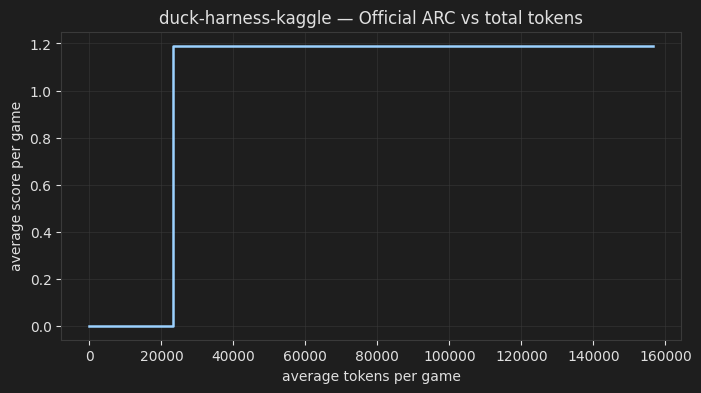
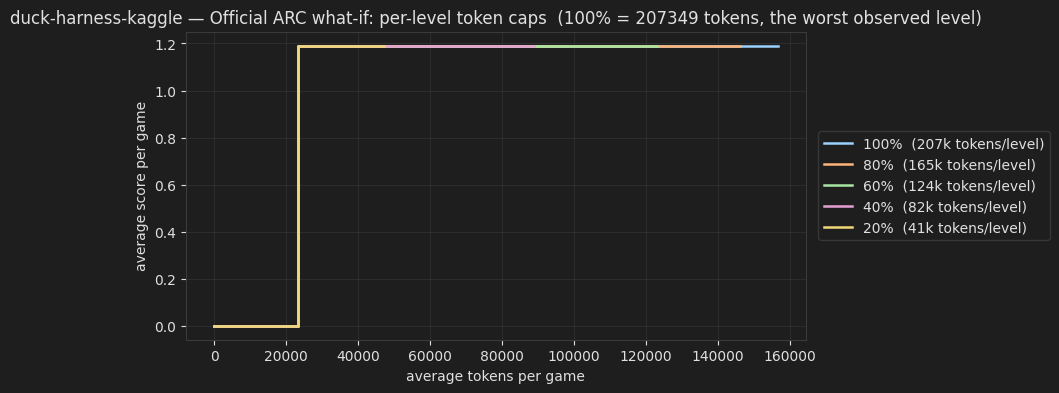
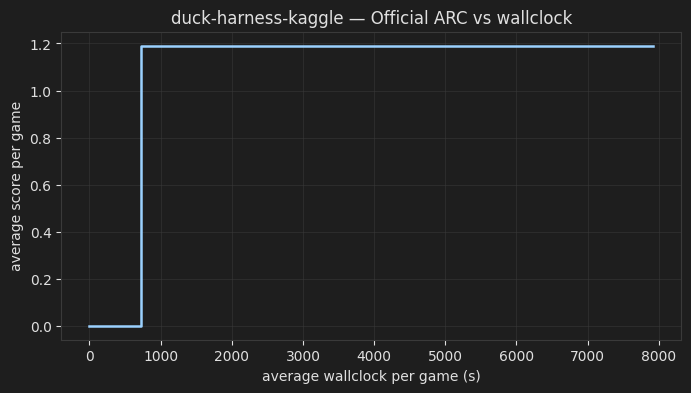
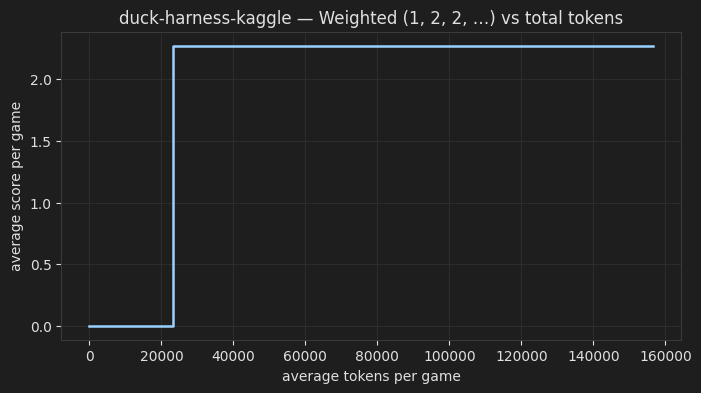
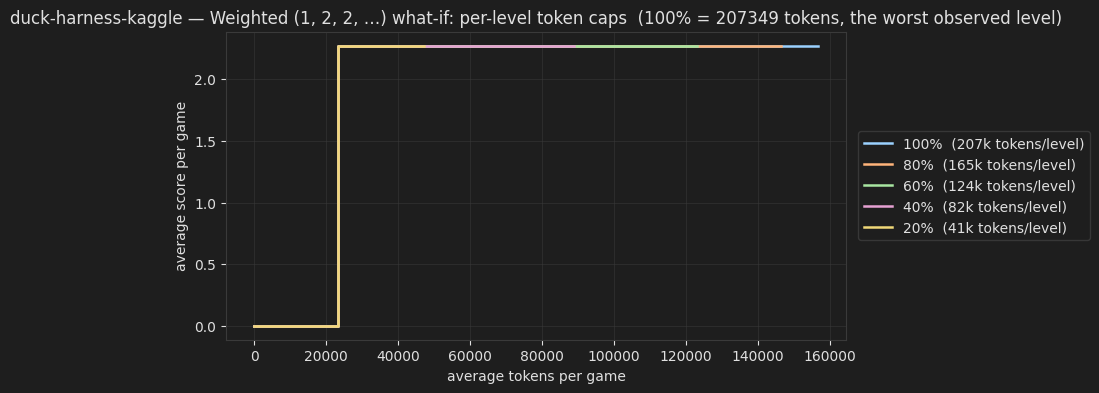
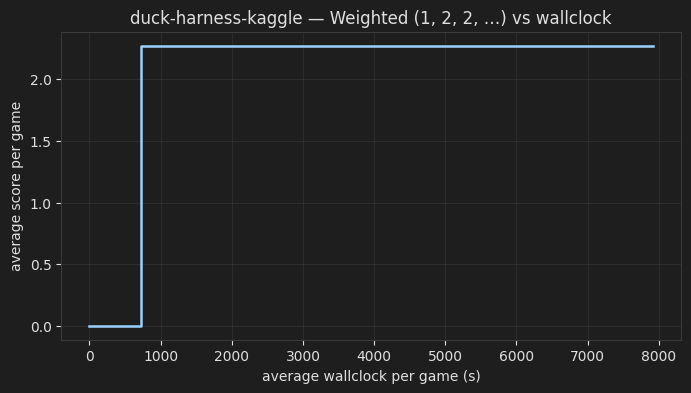
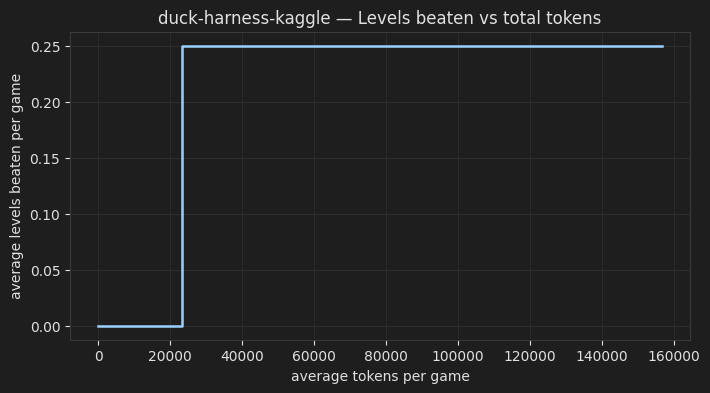
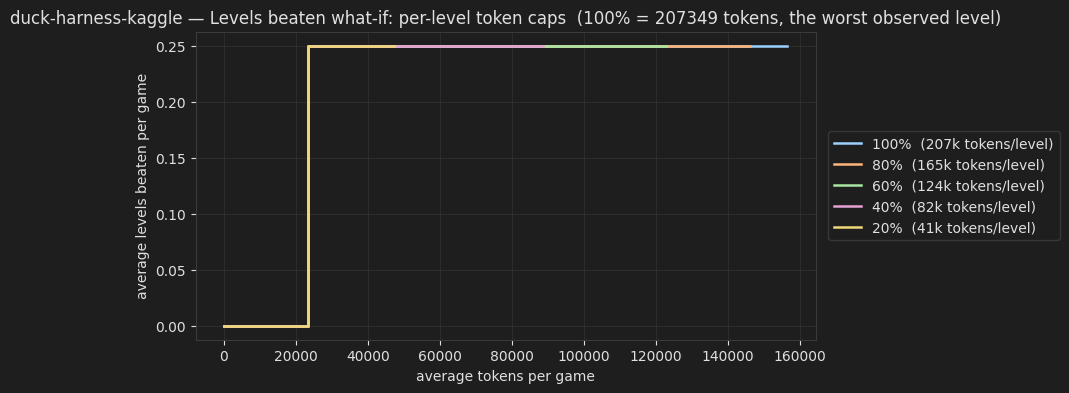
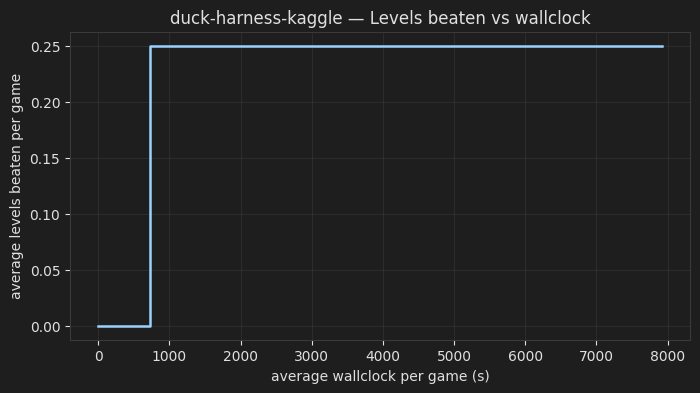
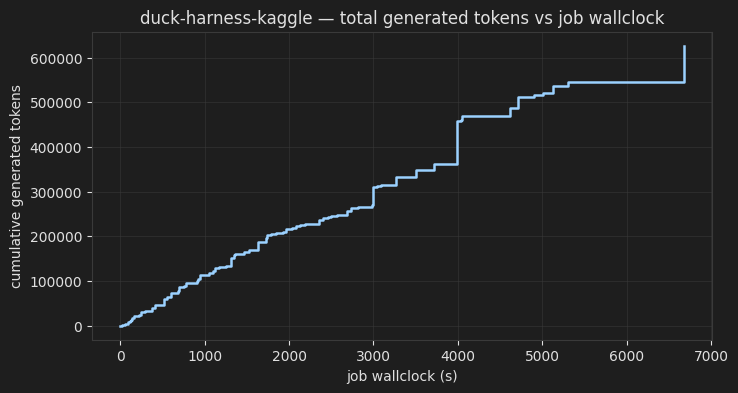
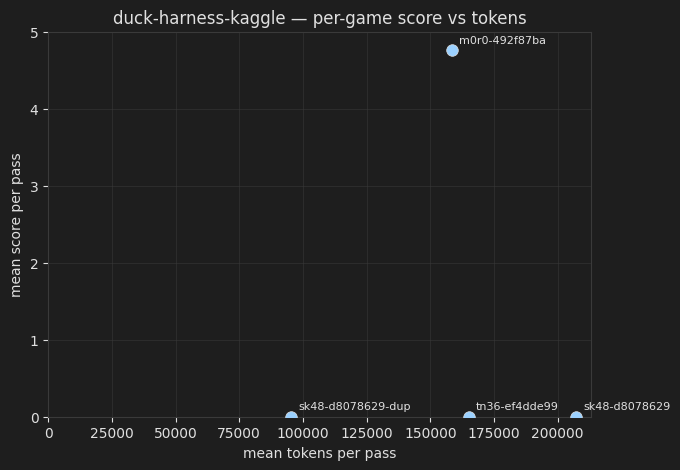
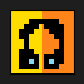
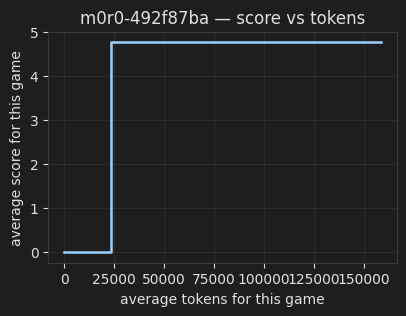
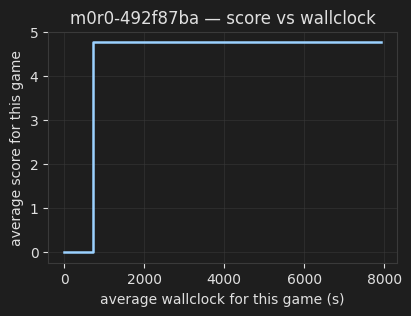
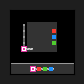
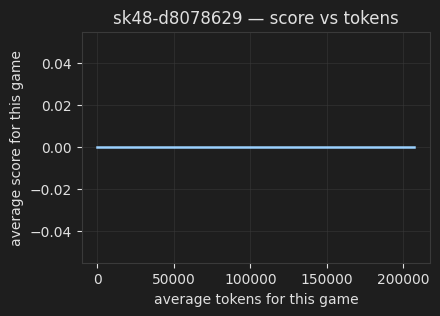
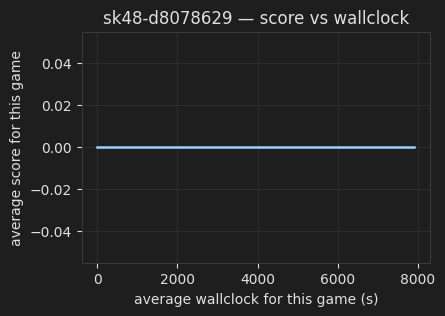
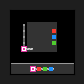
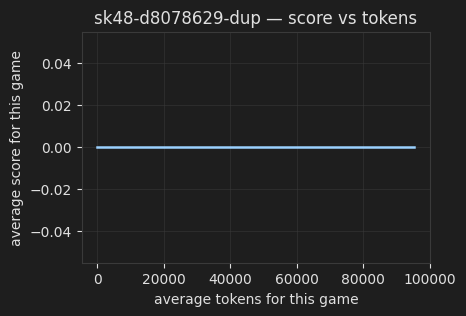
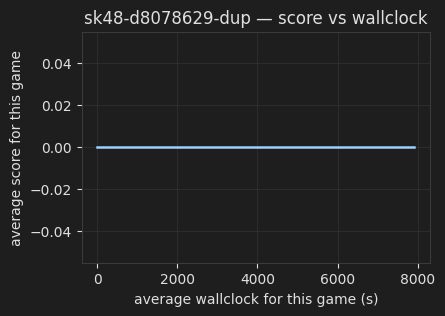
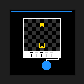
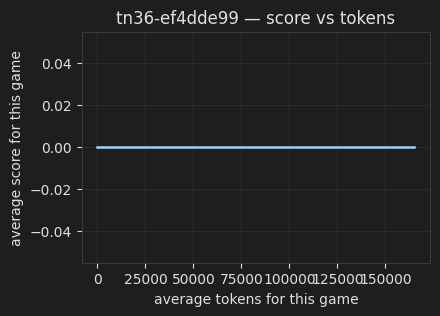
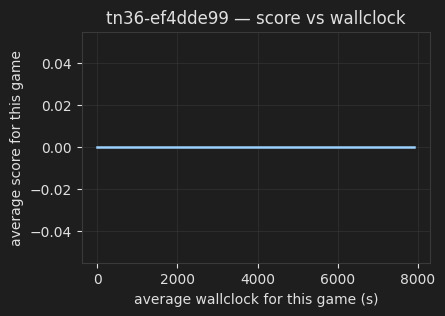
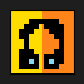
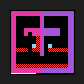
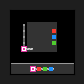
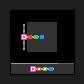
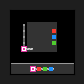
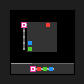
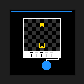
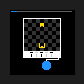

In [8]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")